In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
ORANGE_LINE_DATA = "orange_line_merged.csv"

data = pd.read_csv(ORANGE_LINE_DATA)
print(data.head())
print(data.columns)

    trip_id  stop_id  stop_sequence      arrival_time_schedule  \
0  70525422    70033            170  2025-11-05 14:56:00-05:00   
1  70525422    70035            180  2025-11-05 15:00:00-05:00   
2  70525430    70029            140  2025-11-05 14:56:00-05:00   
3  70525430    70031            150  2025-11-05 14:58:00-05:00   
4  70525430    70279            160  2025-11-05 15:00:00-05:00   

     departure_time_schedule  direction_id_schedule  \
0  2025-11-05 14:56:00-05:00                      1   
1  2025-11-05 15:00:00-05:00                      1   
2  2025-11-05 14:56:00-05:00                      1   
3  2025-11-05 14:58:00-05:00                      1   
4  2025-11-05 15:00:00-05:00                      1   

       timestamp_collected_schedule schedule_type_schedule  \
0  2025-11-05T14:55:04.295171-05:00                planned   
1  2025-11-05T14:55:04.295171-05:00                planned   
2  2025-11-05T14:55:04.295171-05:00                planned   
3  2025-11-05T14:55:04.2

In [3]:
# group the data based on each hour of the day
# find the average delay given each hour of the day and plot it
data["departure_time_schedule"] = pd.to_datetime(data["departure_time_schedule"])

hourly_mean = data.groupby(data['departure_time_schedule'].dt.hour)['delay_minutes'].mean()
print(hourly_mean)

departure_time_schedule
14   -1.196569
15   -1.120905
16   -0.986739
17    0.140347
18    3.236795
19    4.526731
20    3.987793
21    0.896564
22   -1.517825
23   -1.832546
Name: delay_minutes, dtype: float64


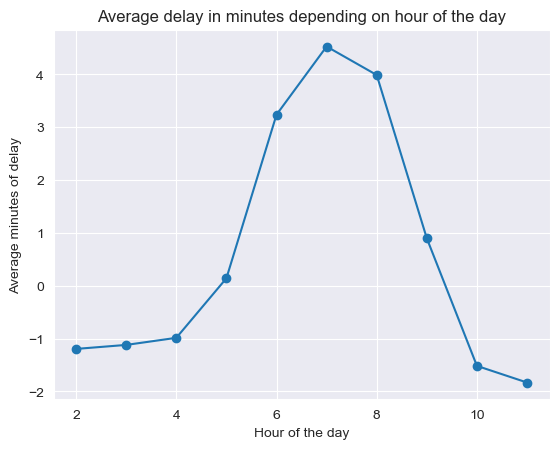

In [4]:
# Visualization #1: Finding when avg delay is worst given hour of the day
plt.plot((data['departure_time_schedule'].dt.hour.unique()-12), hourly_mean, marker='o')
plt.xlabel("Hour of the day")
plt.ylabel("Average minutes of delay")
plt.title("Average delay in minutes depending on hour of the day")
plt.grid(True)
plt.show()

In [5]:
import altair as alt

#graph delay in minutes per hour based on stop_id
data['hour'] = data['departure_time_schedule'].dt.hour

# group the data by the stop_id and for each hour find the mean delay minutes
avg_delay = data.groupby(['stop_id', 'hour'])['delay_minutes'].mean().reset_index()

In [8]:
chart = alt.Chart(avg_delay).mark_line(point=True).encode(
    x = alt.X('adjusted_hour:Q', title="Hour"),
    y = alt.Y('delay_minutes:Q', title="Average Delay (minutes)"),
    color = alt.Color('stop_id:N'),
    tooltip=["delay_minutes"]
).transform_calculate(
    adjusted_hour="datum.hour - 12"
).properties(
    width = 200,
    height = 200,
    title = "Average Delay in Minutes for each Stop"
)

chart

alt.Chart(...)

In [6]:
# Visualization #2 (Interactive): Based on orange line stop, what is the average delay given the hour of the day
# select the stop_id you want to display
select_stop = alt.binding_radio(options=avg_delay["stop_id"].unique(), name="Stop Selection:")

selection = alt.selection_point(
    fields=['stop_id'], 
    bind=select_stop
)

main_chart = (alt.Chart(avg_delay).mark_line(point=True).encode(
    x=alt.X('hour:Q', title="Hour"),
    y=alt.Y('delay_minutes:Q', title="Average Delay (min)"),
    color=alt.condition(
            selection,
            alt.Color('stop_id:N'),
            alt.value('lightgray')
    ),
    opacity=alt.condition(
            selection,
            alt.value(1.0),  
            alt.value(0.3)    
    ),
    tooltip=['stop_id', 'hour', 'delay_minutes']
).transform_calculate(
    adjusted_hour="datum.hour - 12"
).properties(
        width=350,
        height=250,
        title='Average Delay per Hour (All Stops)'
).add_params(selection)
)

selected_chart = (alt.Chart(avg_delay).transform_filter(selection).mark_line(point=True).encode(
        x=alt.X('hour:Q', title="Hour"),
        y=alt.Y('delay_minutes:Q', title="Average Delay (min)")
).transform_calculate(
    adjusted_hour="datum.hour - 12"
).properties(
    width=350,
    height=250,
    title='Selected Stop Delay'
)
)

final_chart = main_chart | selected_chart

final_chart

# final_chart.save("avg_delay_min_per_stop.json")

alt.HConcatChart(...)

In [ ]:
# Visualization #3: histogram of average delay minutes for each hour

histogram = alt.Chart(data).mark_bar().encode(
    x=alt.X('hour:Q', bin=True, title='Hour'),
    y=alt.Y('delay_minutes:Q', title='Delayed minutes'),
    tooltip=['hour', 'delay_minutes']
).properties(
    width=350,
    height=250,
    title='Distribution of Average Delay over the Hours'
)